# Metrics comparison between symbolic and numerical IK 

## Imports 

In [23]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error, combined_error

In [24]:
test = "circle"

filepath_sym = f'data/sym_{test}_data.csv'
filepath_num = f'data/num_{test}_data.csv'

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,0.589058,-98.915319,-9.316243,15.805070,-24.743783,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0..."
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,0.693520,-98.622426,-9.431666,15.431137,-24.713025,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0..."
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,0.794002,-98.326003,-9.542270,15.055383,-24.686194,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1920 non-null   float64
 1   l_q0         1920 non-null   float64
 2   l_q1         1920 non-null   float64
 3   l_q2         1920 non-null   float64
 4   l_q3         1920 non-null   float64
 5   l_q4         1920 non-null   float64
 6   l_q5         1920 non-null   float64
 7   l_q6         1920 non-null   float64
 8   r_q0         1920 non-null   float64
 9   r_q1         1920 non-null   float64
 10  r_q2         1920 non-null   float64
 11  r_q3         1920 non-null   float64
 12  r_q4         1920 non-null   float64
 13  r_q5         1920 non-null   float64
 14  r_q6         1920 non-null   float64
 15  l_pose       1920 non-null   object 
 16  l_real_pose  1920 non-null   object 
 17  r_pose       1920 non-null   object 
 18  r_real_pose  1920 non-null   object 
dtypes: flo

In [25]:
def parse_pose_matrix(matrix_str):
    """Convert a string of a matrix into a NumPy array."""
    return np.array(ast.literal_eval(matrix_str))

In [26]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])
    l_comb = combined_error(l_pos, l_rot)

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)
    l_comb_errs.append(l_comb)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])
    r_comb = combined_error(r_pos, r_rot)

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)
    r_comb_errs.append(r_comb)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs
df_sym["l_combined_err"] = l_comb_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs
df_sym["r_combined_err"] = r_comb_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,l_combined_err,r_pos_err,r_rot_err,r_combined_err
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0...",2.959706e-07,0.000002,3.110345e-07,2.588545e-07,0.000001,2.713501e-07
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0...",2.876167e-07,0.000002,3.030927e-07,2.496754e-07,0.000001,2.622184e-07
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-...",3.070340e-07,0.000002,3.221633e-07,2.672608e-07,0.000001,2.794529e-07


In [27]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,l_combined_err,r_pos_err,r_rot_err,r_combined_err
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0...",2.959706e-07,0.000002,3.110345e-07,2.588545e-07,0.000001,2.713501e-07
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0...",2.876167e-07,0.000002,3.030927e-07,2.496754e-07,0.000001,2.622184e-07
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,...,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-...",3.070340e-07,0.000002,3.221633e-07,2.672608e-07,0.000001,2.794529e-07


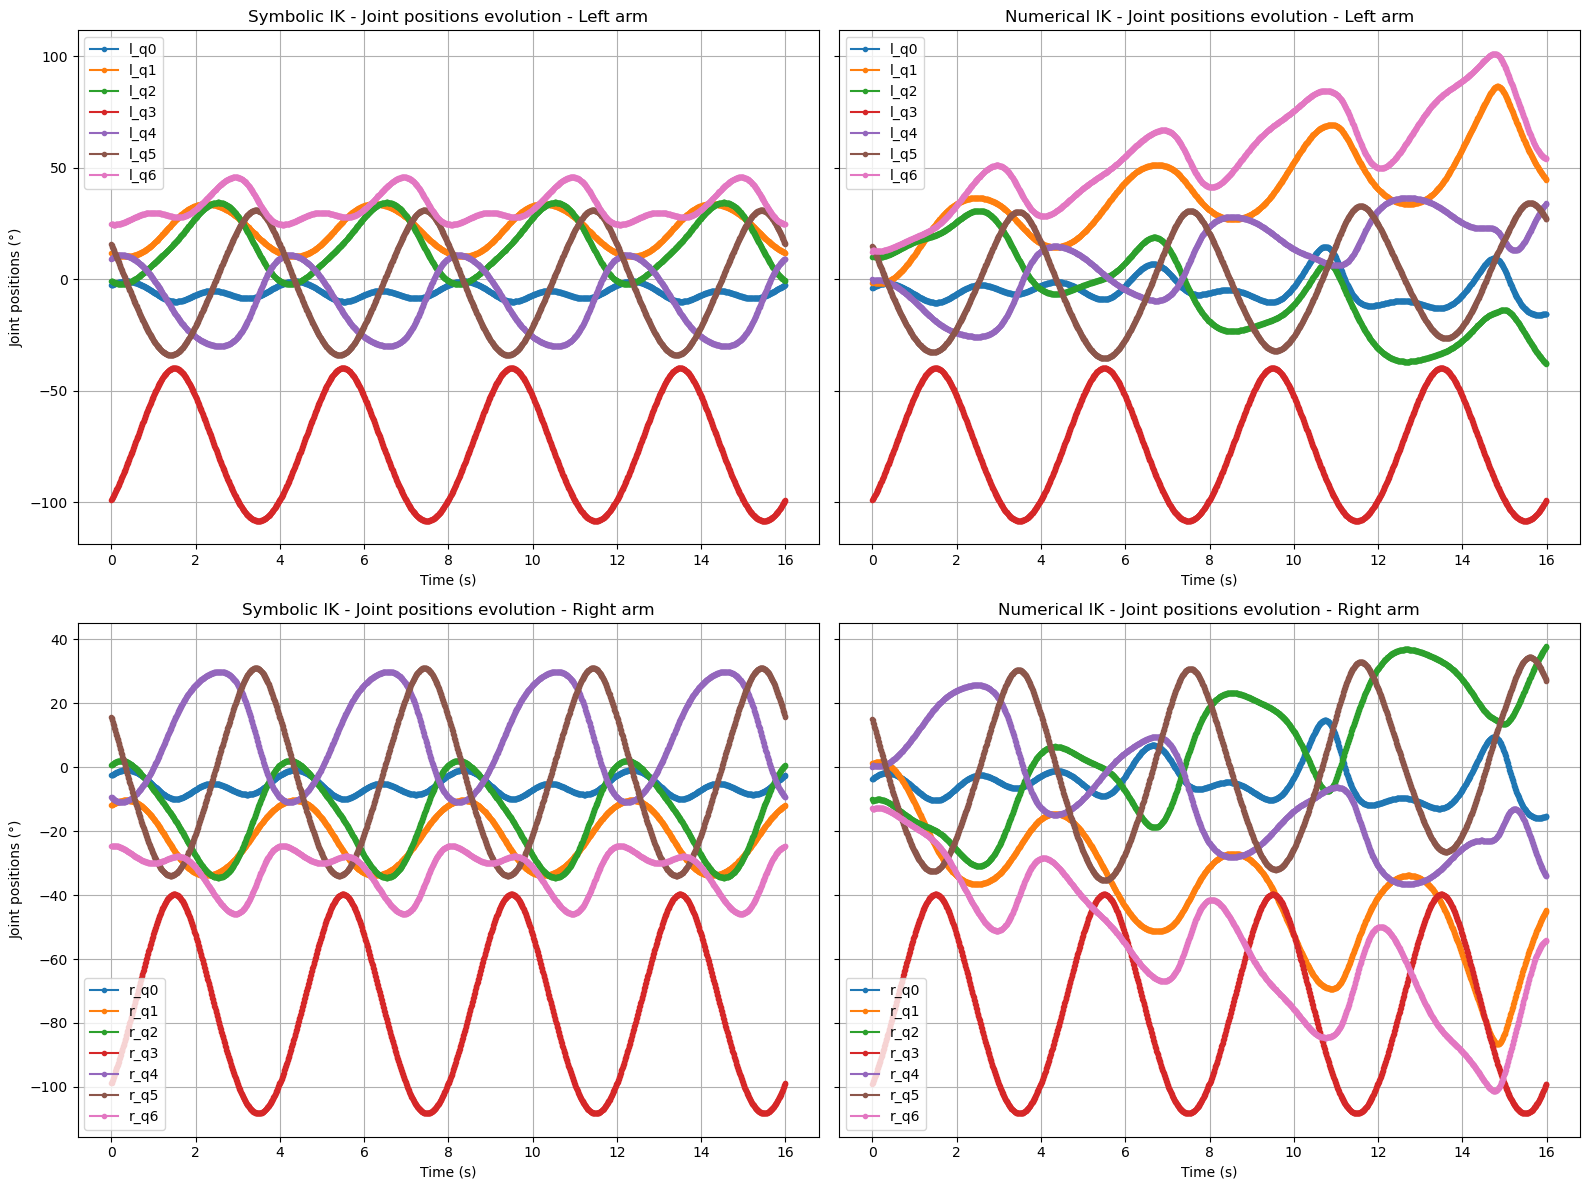

In [28]:
l_joint_cols = ["l_q0", "l_q1", "l_q2", "l_q3", "l_q4", "l_q5", "l_q6"]
r_joint_cols = ["r_q0", "r_q1", "r_q2", "r_q3", "r_q4", "r_q5", "r_q6"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey='row')

for col in l_joint_cols:
    axes[0, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[0, 0].set_title("Symbolic IK - Joint positions evolution - Left arm")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Joint positions (°)")
axes[0, 0].legend()
axes[0, 0].grid(True)

for col in l_joint_cols:
    axes[0, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[0, 1].set_title("Numerical IK - Joint positions evolution - Left arm")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

for col in r_joint_cols:
    axes[1, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[1, 0].set_title("Symbolic IK - Joint positions evolution - Right arm")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Joint positions (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

for col in r_joint_cols:
    axes[1, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[1, 1].set_title("Numerical IK - Joint positions evolution - Right arm")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)


plt.tight_layout()
plt.show()

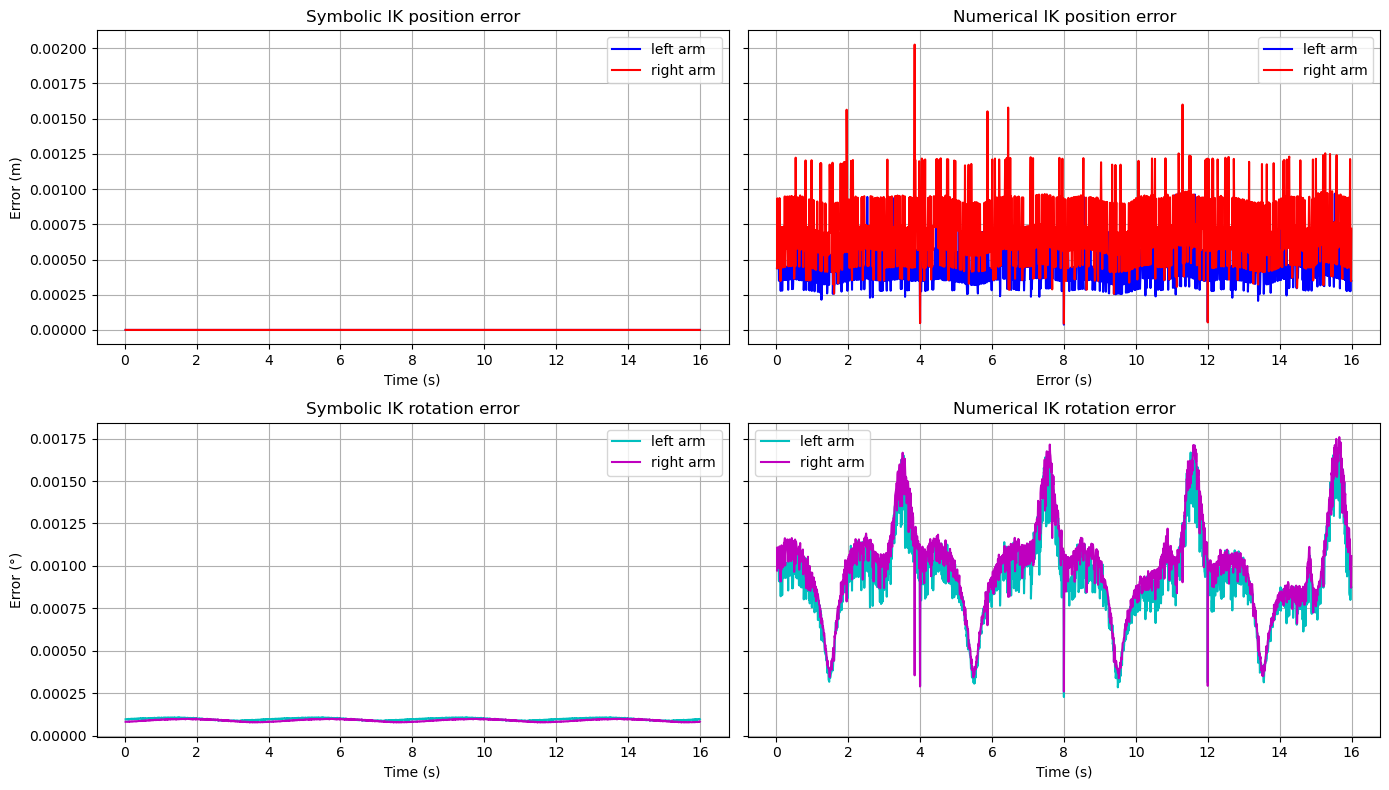

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')

axes[0, 0].plot(df_sym["time"][3:], df_sym["l_pos_err"][3:], label="left arm", color="blue")
axes[0, 0].plot(df_sym["time"][3:], df_sym["r_pos_err"][3:], label="right arm", color="red")
axes[0, 0].set_title("Symbolic IK position error")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Error (m)")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(df_num["time"][3:], df_num["l_pos_err"][3:], label="left arm", color="blue")
axes[0, 1].plot(df_num["time"][3:], df_num["r_pos_err"][3:], label="right arm", color="red")
axes[0, 1].set_title("Numerical IK position error")
axes[0, 1].set_xlabel("Error (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(df_sym["time"][3:], np.rad2deg(df_sym["l_rot_err"][3:]), label="left arm", color="c")
axes[1, 0].plot(df_sym["time"][3:], np.rad2deg(df_sym["r_rot_err"][3:]), label="right arm", color="m")
axes[1, 0].set_title("Symbolic IK rotation error")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Error (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(df_num["time"][3:], np.rad2deg(df_num["l_rot_err"][3:]), label="left arm", color="c")
axes[1, 1].plot(df_num["time"][3:], np.rad2deg(df_num["r_rot_err"][3:]), label="right arm", color="m")
axes[1, 1].set_title("Numerical IK rotation error")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


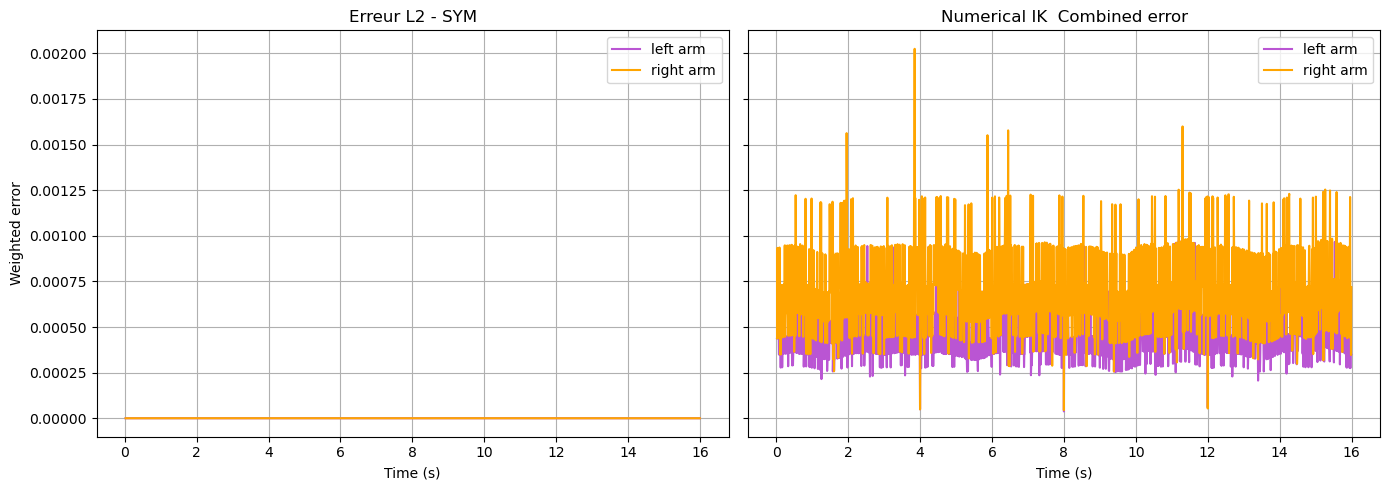

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

lambda_theta = 1e-6 / np.deg2rad(1) ** 2

axes[0].plot(df_sym["time"][3:], combined_error(df_sym["l_pos_err"], df_sym["l_rot_err"], lambda_theta=lambda_theta)[3:], label="left arm", color="mediumorchid")
axes[0].plot(df_sym["time"][3:], combined_error(df_sym["r_pos_err"], df_sym["r_rot_err"], lambda_theta=lambda_theta)[3:], label="right arm", color="orange")
axes[0].set_title("Erreur L2 - SYM")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Weighted error")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_num["time"][3:], combined_error(df_num["l_pos_err"], df_num["l_rot_err"], lambda_theta=lambda_theta)[3:], label="left arm", color="mediumorchid")
axes[1].plot(df_num["time"][3:], combined_error(df_num["r_pos_err"], df_num["r_rot_err"], lambda_theta=lambda_theta)[3:], label="right arm", color="orange")
axes[1].set_title("Numerical IK  Combined error")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
